### Note. This is the RF and LASSO Gridsearch Optimized version
### The inital version's conditions were
### RF trees=500 leaves=2  LASSO Alphas=100  Iterations=50,000


In [ ]:
!pip install -q pandas numpy scikit-learn matplotlib joblib

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from google.colab import drive, data_table

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

print("Imports complete.")

Imports complete.


In [ ]:
# Mount Google Drive
drive.mount("/content/drive")

# Path to your saved feature file
FEATURE_PATH = "/content/drive/MyDrive/459/Project/Perovskite_features.pkl"

# Output folder
OUTPUT_DIR = "/content/drive/MyDrive/459/Project/ML_from_saved_features"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Feature file:", FEATURE_PATH)
print("Output folder:", OUTPUT_DIR)

if not os.path.exists(FEATURE_PATH):
    raise FileNotFoundError(
        f"Could not find {FEATURE_PATH}. Check your Google Drive path."
    )

Mounted at /content/drive
Feature file: /content/drive/MyDrive/459/Project/Perovskite_features.pkl
Output folder: /content/drive/MyDrive/459/Project/ML_from_saved_features


In [ ]:
df = pd.read_pickle(FEATURE_PATH)

print(f"Loaded feature dataframe: {df.shape}")
print("Number of columns:", len(df.columns))

priority_cols = [
    "material_id",
    "formula",
    "band_gap",
    "energy_above_hull",
    "formation_energy_per_atom",
    "is_stable",
    "is_metal",
    "theoretical",
    "spg_number",
    "spg_symbol",
]

priority_cols = [c for c in priority_cols if c in df.columns]
other_cols = [c for c in df.columns if c not in priority_cols]

data_table.enable_dataframe_formatter()

df[priority_cols + other_cols].head()

Loaded feature dataframe: (2179, 309)
Number of columns: 309


,material_id,formula,band_gap,energy_above_hull,formation_energy_per_atom,is_stable,is_metal,theoretical,spg_number,spg_symbol,density_MP,volume,nsites,efermi,total_magnetization,a,b,c,alpha,beta,gamma,crystal_system_MP,MagpieData minimum Number,MagpieData maximum Number,MagpieData range Number,MagpieData mean Number,MagpieData avg_dev Number,MagpieData mode Number,MagpieData minimum MendeleevNumber,MagpieData maximum MendeleevNumber,MagpieData range MendeleevNumber,MagpieData mean MendeleevNumber,MagpieData avg_dev MendeleevNumber,MagpieData mode MendeleevNumber,MagpieData minimum AtomicWeight,MagpieData maximum AtomicWeight,MagpieData range AtomicWeight,MagpieData mean AtomicWeight,MagpieData avg_dev AtomicWeight,MagpieData mode AtomicWeight,MagpieData minimum MeltingT,MagpieData maximum MeltingT,MagpieData range MeltingT,MagpieData mean MeltingT,MagpieData avg_dev MeltingT,MagpieData mode MeltingT,MagpieData minimum Column,MagpieData maximum Column,MagpieData range Column,MagpieData mean Column,MagpieData avg_dev Column,MagpieData mode Column,MagpieData minimum Row,MagpieData maximum Row,MagpieData range Row,MagpieData mean Row,MagpieData avg_dev Row,MagpieData mode Row,MagpieData minimum CovalentRadius,MagpieData maximum CovalentRadius,MagpieData range CovalentRadius,MagpieData mean CovalentRadius,MagpieData avg_dev CovalentRadius,MagpieData mode CovalentRadius,MagpieData minimum Electronegativity,MagpieData maximum Electronegativity,MagpieData range Electronegativity,MagpieData mean Electronegativity,MagpieData avg_dev Electronegativity,MagpieData mode Electronegativity,MagpieData minimum NsValence,MagpieData maximum NsValence,MagpieData range NsValence,MagpieData mean NsValence,MagpieData avg_dev NsValence,MagpieData mode NsValence,MagpieData minimum NpValence,MagpieData maximum NpValence,MagpieData range NpValence,MagpieData mean NpValence,MagpieData avg_dev NpValence,MagpieData mode NpValence,MagpieData minimum NdValence,MagpieData maximum NdValence,MagpieData range NdValence,MagpieData mean NdValence,MagpieData avg_dev NdValence,MagpieData mode NdValence,MagpieData minimum NfValence,MagpieData maximum NfValence,MagpieData range NfValence,MagpieData mean NfValence,MagpieData avg_dev NfValence,MagpieData mode NfValence,MagpieData minimum NValence,MagpieData maximum NValence,MagpieData range NValence,MagpieData mean NValence,MagpieData avg_dev NValence,MagpieData mode NValence,...,Y,Zr,Nb,Mo,Tc,Ru,Rh,Pd,Ag,Cd,In,Sn,Sb,Te,I,Xe,Cs,Ba,La,Ce,Pr,Nd,Pm,Sm,Eu,Gd,Tb,Dy,Ho,Er,Tm,Yb,Lu,Hf,Ta,W,Re,Os,Ir,Pt,Au,Hg,Tl,Pb,Bi,Po,At,Rn,Fr,Ra,Ac,Th,Pa,U,Np,Pu,Am,Cm,Bk,Cf,Es,Fm,Md,No,Lr,Rf,Db,Sg,Bh,Hs,Mt,Ds,Rg,Cn,Nh,Fl,Mc,Lv,Ts,Og,transition metal fraction,band center,density,vpa,packing fraction,spacegroup_num,crystal_system,crystal_system_int,is_centrosymmetric,n_symmetry_ops,mean absolute deviation in relative bond length,max relative bond length,min relative bond length,minimum neighbor distance variation,maximum neighbor distance variation,range neighbor distance variation,mean neighbor distance variation,avg_dev neighbor distance variation,mean absolute deviation in relative cell size,max packing efficiency
0,mp-cezpz,CaFeO3,0.0,0.052147,-2.176372,False,True,True,221,Pm-3m,4.231856,56.473274,5,3.318961,4.060209,3.836610,3.836610,3.836610,90.00000,90.00000,90.000000,Cubic,8.0,26.0,18.0,14.0,7.20,8.0,7.0,87.0,80.0,64.6,26.88,87.0,15.9994,55.845000,39.845600,28.784240,15.341808,15.999400,54.80,1811.0,1756.20,618.080,675.9360,54.8,2.0,16.0,14.0,11.6,5.28,16.0,2.0,4.0,2.0,2.8,0.96,2.0,66.0,176.0,110.0,101.2,42.24,66.0,1.00,3.44,2.44,2.630,0.9720,3.44,2.0,2.0,0.0,2.0,0.00,2.0,0.0,4.0,4.0,2.4,1.92,4.0,0.0,6.0,6.0,1.2,1.92,0.0,0.0,0.0,0.0,0.0,0.00,0.0,2.0,8.0,6.0,5.6,1.44,6.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.2,5.

In [ ]:
# ============================================================
# Choose prediction target
# ============================================================

#target_col = "band_gap"
target_col = "energy_above_hull"

if target_col not in df.columns:
    raise ValueError(f"{target_col} not found in dataframe. Available columns include:\n{df.columns.tolist()}")

# Keep only numeric and boolean columns
num_df = df.select_dtypes(include=[np.number, bool]).copy()

# Convert boolean columns to 0/1
for col in num_df.columns:
    if num_df[col].dtype == bool:
        num_df[col] = num_df[col].astype(int)

# Replace infinite values with NaN
num_df = num_df.replace([np.inf, -np.inf], np.nan)

# Drop columns that are completely NaN
num_df = num_df.dropna(axis=1, how="all")

# Drop rows with missing target
num_df = num_df.dropna(subset=[target_col]).copy()

print("Numeric dataframe shape:", num_df.shape)
print("Target:", target_col)

display(num_df.head())

Numeric dataframe shape: (2179, 304)
Target: energy_above_hull


,band_gap,energy_above_hull,formation_energy_per_atom,density_MP,volume,nsites,is_stable,is_metal,theoretical,efermi,total_magnetization,a,b,c,alpha,beta,gamma,spg_number,MagpieData minimum Number,MagpieData maximum Number,MagpieData range Number,MagpieData mean Number,MagpieData avg_dev Number,MagpieData mode Number,MagpieData minimum MendeleevNumber,MagpieData maximum MendeleevNumber,MagpieData range MendeleevNumber,MagpieData mean MendeleevNumber,MagpieData avg_dev MendeleevNumber,MagpieData mode MendeleevNumber,MagpieData minimum AtomicWeight,MagpieData maximum AtomicWeight,MagpieData range AtomicWeight,MagpieData mean AtomicWeight,MagpieData avg_dev AtomicWeight,MagpieData mode AtomicWeight,MagpieData minimum MeltingT,MagpieData maximum MeltingT,MagpieData range MeltingT,MagpieData mean MeltingT,MagpieData avg_dev MeltingT,MagpieData mode MeltingT,MagpieData minimum Column,MagpieData maximum Column,MagpieData range Column,MagpieData mean Column,MagpieData avg_dev Column,MagpieData mode Column,MagpieData minimum Row,MagpieData maximum Row,MagpieData range Row,MagpieData mean Row,MagpieData avg_dev Row,MagpieData mode Row,MagpieData minimum CovalentRadius,MagpieData maximum CovalentRadius,MagpieData range CovalentRadius,MagpieData mean CovalentRadius,MagpieData avg_dev CovalentRadius,MagpieData mode CovalentRadius,MagpieData minimum Electronegativity,MagpieData maximum Electronegativity,MagpieData range Electronegativity,MagpieData mean Electronegativity,MagpieData avg_dev Electronegativity,MagpieData mode Electronegativity,MagpieData minimum NsValence,MagpieData maximum NsValence,MagpieData range NsValence,MagpieData mean NsValence,MagpieData avg_dev NsValence,MagpieData mode NsValence,MagpieData minimum NpValence,MagpieData maximum NpValence,MagpieData range NpValence,MagpieData mean NpValence,MagpieData avg_dev NpValence,MagpieData mode NpValence,MagpieData minimum NdValence,MagpieData maximum NdValence,MagpieData range NdValence,MagpieData mean NdValence,MagpieData avg_dev NdValence,MagpieData mode NdValence,MagpieData minimum NfValence,MagpieData maximum NfValence,MagpieData range NfValence,MagpieData mean NfValence,MagpieData avg_dev NfValence,MagpieData mode NfValence,MagpieData minimum NValence,MagpieData maximum NValence,MagpieData range NValence,MagpieData mean NValence,MagpieData avg_dev NValence,MagpieData mode NValence,MagpieData minimum NsUnfilled,MagpieData maximum NsUnfilled,MagpieData range NsUnfilled,MagpieData mean NsUnfilled,...,Sr,Y,Zr,Nb,Mo,Tc,Ru,Rh,Pd,Ag,Cd,In,Sn,Sb,Te,I,Xe,Cs,Ba,La,Ce,Pr,Nd,Pm,Sm,Eu,Gd,Tb,Dy,Ho,Er,Tm,Yb,Lu,Hf,Ta,W,Re,Os,Ir,Pt,Au,Hg,Tl,Pb,Bi,Po,At,Rn,Fr,Ra,Ac,Th,Pa,U,Np,Pu,Am,Cm,Bk,Cf,Es,Fm,Md,No,Lr,Rf,Db,Sg,Bh,Hs,Mt,Ds,Rg,Cn,Nh,Fl,Mc,Lv,Ts,Og,transition metal fraction,band center,density,vpa,packing fraction,spacegroup_num,crystal_system_int,is_centrosymmetric,n_symmetry_ops,mean absolute deviation in relative bond length,max relative bond length,min relative bond length,minimum neighbor distance variation,maximum neighbor distance variation,range neighbor distance variation,mean neighbor distance variation,avg_dev neighbor distance variation,mean absolute deviation in relative cell size,max packing efficiency
0,0.0,0.052147,-2.176372,4.231856,56.473274,5,0,1,1,3.318961,4.060209,3.836610,3.836610,3.836610,90.00000,90.00000,90.000000,221,8.0,26.0,18.0,14.0,7.20,8.0,7.0,87.0,80.0,64.6,26.88,87.0,15.9994,55.845000,39.845600,28.784240,15.341808,15.999400,54.80,1811.0,1756.20,618.080,675.9360,54.8,2.0,16.0,14.0,11.6,5.28,16.0,2.0,4.0,2.0,2.8,0.96,2.0,66.0,176.0,110.0,101.2,42.24,66.0,1.00,3.44,2.44,2.630,0.9720,3.44,2.0,2.0,0.0,2.0,0.00,2.0,0.0,4.0,4.0,2.4,1.92,4.0,0.0,6.0,6.0,1.2,1.92,0.0,0.0,0.0,0.0,0.0,0.00,0.0,2.0,8.0,6.0,5.6,1.44,6.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,

In [ ]:
original_cols = set(df.columns)
numeric_cols = set(num_df.columns)

dropped_in_cell5 = sorted(original_cols - numeric_cols)

print("Columns dropped in this cell because they were non-numeric:")
print(dropped_in_cell5)
print("Number dropped:", len(dropped_in_cell5))

Columns dropped in this cell because they were non-numeric:
['crystal_system', 'crystal_system_MP', 'formula', 'material_id', 'spg_symbol']
Number dropped: 5


In [ ]:
# ============================================================
# Define X and y
# ============================================================

y = num_df[target_col].copy()
X = num_df.drop(columns=[target_col]).copy()

# Remove other target-like columns to avoid leakage
possible_leakage_cols = [
    "band_gap",
    "energy_above_hull",
    "formation_energy_per_atom",
]

for col in possible_leakage_cols:
    if col != target_col and col in X.columns:
        X = X.drop(columns=[col])

# Fill missing values in X using medians
for col in X.columns:
    X[col] = X[col].fillna(X[col].median())

print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())

X shape: (2179, 301)
y shape: (2179,)


,density_MP,volume,nsites,is_stable,is_metal,theoretical,efermi,total_magnetization,a,b,c,alpha,beta,gamma,spg_number,MagpieData minimum Number,MagpieData maximum Number,MagpieData range Number,MagpieData mean Number,MagpieData avg_dev Number,MagpieData mode Number,MagpieData minimum MendeleevNumber,MagpieData maximum MendeleevNumber,MagpieData range MendeleevNumber,MagpieData mean MendeleevNumber,MagpieData avg_dev MendeleevNumber,MagpieData mode MendeleevNumber,MagpieData minimum AtomicWeight,MagpieData maximum AtomicWeight,MagpieData range AtomicWeight,MagpieData mean AtomicWeight,MagpieData avg_dev AtomicWeight,MagpieData mode AtomicWeight,MagpieData minimum MeltingT,MagpieData maximum MeltingT,MagpieData range MeltingT,MagpieData mean MeltingT,MagpieData avg_dev MeltingT,MagpieData mode MeltingT,MagpieData minimum Column,MagpieData maximum Column,MagpieData range Column,MagpieData mean Column,MagpieData avg_dev Column,MagpieData mode Column,MagpieData minimum Row,MagpieData maximum Row,MagpieData range Row,MagpieData mean Row,MagpieData avg_dev Row,MagpieData mode Row,MagpieData minimum CovalentRadius,MagpieData maximum CovalentRadius,MagpieData range CovalentRadius,MagpieData mean CovalentRadius,MagpieData avg_dev CovalentRadius,MagpieData mode CovalentRadius,MagpieData minimum Electronegativity,MagpieData maximum Electronegativity,MagpieData range Electronegativity,MagpieData mean Electronegativity,MagpieData avg_dev Electronegativity,MagpieData mode Electronegativity,MagpieData minimum NsValence,MagpieData maximum NsValence,MagpieData range NsValence,MagpieData mean NsValence,MagpieData avg_dev NsValence,MagpieData mode NsValence,MagpieData minimum NpValence,MagpieData maximum NpValence,MagpieData range NpValence,MagpieData mean NpValence,MagpieData avg_dev NpValence,MagpieData mode NpValence,MagpieData minimum NdValence,MagpieData maximum NdValence,MagpieData range NdValence,MagpieData mean NdValence,MagpieData avg_dev NdValence,MagpieData mode NdValence,MagpieData minimum NfValence,MagpieData maximum NfValence,MagpieData range NfValence,MagpieData mean NfValence,MagpieData avg_dev NfValence,MagpieData mode NfValence,MagpieData minimum NValence,MagpieData maximum NValence,MagpieData range NValence,MagpieData mean NValence,MagpieData avg_dev NValence,MagpieData mode NValence,MagpieData minimum NsUnfilled,MagpieData maximum NsUnfilled,MagpieData range NsUnfilled,MagpieData mean NsUnfilled,MagpieData avg_dev NsUnfilled,MagpieData mode NsUnfilled,MagpieData minimum NpUnfilled,...,Sr,Y,Zr,Nb,Mo,Tc,Ru,Rh,Pd,Ag,Cd,In,Sn,Sb,Te,I,Xe,Cs,Ba,La,Ce,Pr,Nd,Pm,Sm,Eu,Gd,Tb,Dy,Ho,Er,Tm,Yb,Lu,Hf,Ta,W,Re,Os,Ir,Pt,Au,Hg,Tl,Pb,Bi,Po,At,Rn,Fr,Ra,Ac,Th,Pa,U,Np,Pu,Am,Cm,Bk,Cf,Es,Fm,Md,No,Lr,Rf,Db,Sg,Bh,Hs,Mt,Ds,Rg,Cn,Nh,Fl,Mc,Lv,Ts,Og,transition metal fraction,band center,density,vpa,packing fraction,spacegroup_num,crystal_system_int,is_centrosymmetric,n_symmetry_ops,mean absolute deviation in relative bond length,max relative bond length,min relative bond length,minimum neighbor distance variation,maximum neighbor distance variation,range neighbor distance variation,mean neighbor distance variation,avg_dev neighbor distance variation,mean absolute deviation in relative cell size,max packing efficiency
0,4.231856,56.473274,5,0,1,1,3.318961,4.060209,3.836610,3.836610,3.836610,90.00000,90.00000,90.000000,221,8.0,26.0,18.0,14.0,7.20,8.0,7.0,87.0,80.0,64.6,26.88,87.0,15.9994,55.845000,39.845600,28.784240,15.341808,15.999400,54.80,1811.0,1756.20,618.080,675.9360,54.8,2.0,16.0,14.0,11.6,5.28,16.0,2.0,4.0,2.0,2.8,0.96,2.0,66.0,176.0,110.0,101.2,42.24,66.0,1.00,3.44,2.44,2.630,0.9720,3.44,2.0,2.0,0.0,2.0,0.00,2.0,0.0,4.0,4.0,2.4,1.92,4.0,0.0,6.0,6.0,1.2,1.92,0.0,0.0,0.0,0.0,0.0,0.00,0.0,2.0,8.0,6.0,5.6,1.44,6.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.

In [ ]:
cell5_cols = set(num_df.columns)
cell6_cols = set(X.columns)

dropped_in_cell6 = sorted(cell5_cols - cell6_cols - {target_col})

print("Columns dropped in removing target like columns:")
print(dropped_in_cell6)
print("Number dropped:", len(dropped_in_cell6))

Columns dropped in removing target like columns:
['band_gap', 'formation_energy_per_atom']
Number dropped: 2


In [ ]:
# ============================================================
# Cell 7 — Train/test split
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

display(X_train.head())

Training features: (1743, 301)
Testing features: (436, 301)
Training target: (1743,)
Testing target: (436,)


,density_MP,volume,nsites,is_stable,is_metal,theoretical,efermi,total_magnetization,a,b,c,alpha,beta,gamma,spg_number,MagpieData minimum Number,MagpieData maximum Number,MagpieData range Number,MagpieData mean Number,MagpieData avg_dev Number,MagpieData mode Number,MagpieData minimum MendeleevNumber,MagpieData maximum MendeleevNumber,MagpieData range MendeleevNumber,MagpieData mean MendeleevNumber,MagpieData avg_dev MendeleevNumber,MagpieData mode MendeleevNumber,MagpieData minimum AtomicWeight,MagpieData maximum AtomicWeight,MagpieData range AtomicWeight,MagpieData mean AtomicWeight,MagpieData avg_dev AtomicWeight,MagpieData mode AtomicWeight,MagpieData minimum MeltingT,MagpieData maximum MeltingT,MagpieData range MeltingT,MagpieData mean MeltingT,MagpieData avg_dev MeltingT,MagpieData mode MeltingT,MagpieData minimum Column,MagpieData maximum Column,MagpieData range Column,MagpieData mean Column,MagpieData avg_dev Column,MagpieData mode Column,MagpieData minimum Row,MagpieData maximum Row,MagpieData range Row,MagpieData mean Row,MagpieData avg_dev Row,MagpieData mode Row,MagpieData minimum CovalentRadius,MagpieData maximum CovalentRadius,MagpieData range CovalentRadius,MagpieData mean CovalentRadius,MagpieData avg_dev CovalentRadius,MagpieData mode CovalentRadius,MagpieData minimum Electronegativity,MagpieData maximum Electronegativity,MagpieData range Electronegativity,MagpieData mean Electronegativity,MagpieData avg_dev Electronegativity,MagpieData mode Electronegativity,MagpieData minimum NsValence,MagpieData maximum NsValence,MagpieData range NsValence,MagpieData mean NsValence,MagpieData avg_dev NsValence,MagpieData mode NsValence,MagpieData minimum NpValence,MagpieData maximum NpValence,MagpieData range NpValence,MagpieData mean NpValence,MagpieData avg_dev NpValence,MagpieData mode NpValence,MagpieData minimum NdValence,MagpieData maximum NdValence,MagpieData range NdValence,MagpieData mean NdValence,MagpieData avg_dev NdValence,MagpieData mode NdValence,MagpieData minimum NfValence,MagpieData maximum NfValence,MagpieData range NfValence,MagpieData mean NfValence,MagpieData avg_dev NfValence,MagpieData mode NfValence,MagpieData minimum NValence,MagpieData maximum NValence,MagpieData range NValence,MagpieData mean NValence,MagpieData avg_dev NValence,MagpieData mode NValence,MagpieData minimum NsUnfilled,MagpieData maximum NsUnfilled,MagpieData range NsUnfilled,MagpieData mean NsUnfilled,MagpieData avg_dev NsUnfilled,MagpieData mode NsUnfilled,MagpieData minimum NpUnfilled,...,Sr,Y,Zr,Nb,Mo,Tc,Ru,Rh,Pd,Ag,Cd,In,Sn,Sb,Te,I,Xe,Cs,Ba,La,Ce,Pr,Nd,Pm,Sm,Eu,Gd,Tb,Dy,Ho,Er,Tm,Yb,Lu,Hf,Ta,W,Re,Os,Ir,Pt,Au,Hg,Tl,Pb,Bi,Po,At,Rn,Fr,Ra,Ac,Th,Pa,U,Np,Pu,Am,Cm,Bk,Cf,Es,Fm,Md,No,Lr,Rf,Db,Sg,Bh,Hs,Mt,Ds,Rg,Cn,Nh,Fl,Mc,Lv,Ts,Og,transition metal fraction,band center,density,vpa,packing fraction,spacegroup_num,crystal_system_int,is_centrosymmetric,n_symmetry_ops,mean absolute deviation in relative bond length,max relative bond length,min relative bond length,minimum neighbor distance variation,maximum neighbor distance variation,range neighbor distance variation,mean neighbor distance variation,avg_dev neighbor distance variation,mean absolute deviation in relative cell size,max packing efficiency
1245,6.687745,59.618379,5,0,1,0,8.038022,4.000803,3.906550,3.906550,3.906550,90.0,90.0,90.0,221,8.0,58.0,50.0,21.2,15.84,8.0,15.0,87.0,72.0,65.0,26.40,87.0,15.999400,140.116000,124.116600,48.022060,38.427192,15.999400,54.8,2180.00,2125.20,683.080,753.9360,54.8,3.0,16.0,13.0,11.4,5.52,16.0,2.0,6.0,4.0,3.2,1.44,2.0,66.0,204.0,138.0,108.2,50.64,66.0,1.12,3.44,2.32,2.620,0.9840,3.44,1.0,2.0,1.0,1.8,0.32,2.0,0.0,4.0,4.0,2.4,1.92,4.0,0.0,5.0,5.0,1.2,1.52,0.0,0.0,1.0,1.0,0.2,0.32,0.0,4.0,6.0,2.0,5.6,0.64,6.0,0.0,1.0,1.0,0.2,0.32,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.

In [ ]:
# ============================================================
# Cell 8 — Normalize features
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit scaler ONLY on training data
X_train_scaled_array = scaler.fit_transform(X_train)

# Transform test data using the training-set scaler
X_test_scaled_array = scaler.transform(X_test)

# Convert back to DataFrames so we keep column names
X_train_scaled = pd.DataFrame(
    X_train_scaled_array,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled_array,
    columns=X_test.columns,
    index=X_test.index
)

print("Original X_train:")
display(X_train.head())

print("Normalized X_train:")
display(X_train_scaled.head())

print("Check mean of scaled training features:")
display(X_train_scaled.mean().head())

print("Check std of scaled training features:")
display(X_train_scaled.std().head())

Original X_train:


,density_MP,volume,nsites,is_stable,is_metal,theoretical,efermi,total_magnetization,a,b,c,alpha,beta,gamma,spg_number,MagpieData minimum Number,MagpieData maximum Number,MagpieData range Number,MagpieData mean Number,MagpieData avg_dev Number,MagpieData mode Number,MagpieData minimum MendeleevNumber,MagpieData maximum MendeleevNumber,MagpieData range MendeleevNumber,MagpieData mean MendeleevNumber,MagpieData avg_dev MendeleevNumber,MagpieData mode MendeleevNumber,MagpieData minimum AtomicWeight,MagpieData maximum AtomicWeight,MagpieData range AtomicWeight,MagpieData mean AtomicWeight,MagpieData avg_dev AtomicWeight,MagpieData mode AtomicWeight,MagpieData minimum MeltingT,MagpieData maximum MeltingT,MagpieData range MeltingT,MagpieData mean MeltingT,MagpieData avg_dev MeltingT,MagpieData mode MeltingT,MagpieData minimum Column,MagpieData maximum Column,MagpieData range Column,MagpieData mean Column,MagpieData avg_dev Column,MagpieData mode Column,MagpieData minimum Row,MagpieData maximum Row,MagpieData range Row,MagpieData mean Row,MagpieData avg_dev Row,MagpieData mode Row,MagpieData minimum CovalentRadius,MagpieData maximum CovalentRadius,MagpieData range CovalentRadius,MagpieData mean CovalentRadius,MagpieData avg_dev CovalentRadius,MagpieData mode CovalentRadius,MagpieData minimum Electronegativity,MagpieData maximum Electronegativity,MagpieData range Electronegativity,MagpieData mean Electronegativity,MagpieData avg_dev Electronegativity,MagpieData mode Electronegativity,MagpieData minimum NsValence,MagpieData maximum NsValence,MagpieData range NsValence,MagpieData mean NsValence,MagpieData avg_dev NsValence,MagpieData mode NsValence,MagpieData minimum NpValence,MagpieData maximum NpValence,MagpieData range NpValence,MagpieData mean NpValence,MagpieData avg_dev NpValence,MagpieData mode NpValence,MagpieData minimum NdValence,MagpieData maximum NdValence,MagpieData range NdValence,MagpieData mean NdValence,MagpieData avg_dev NdValence,MagpieData mode NdValence,MagpieData minimum NfValence,MagpieData maximum NfValence,MagpieData range NfValence,MagpieData mean NfValence,MagpieData avg_dev NfValence,MagpieData mode NfValence,MagpieData minimum NValence,MagpieData maximum NValence,MagpieData range NValence,MagpieData mean NValence,MagpieData avg_dev NValence,MagpieData mode NValence,MagpieData minimum NsUnfilled,MagpieData maximum NsUnfilled,MagpieData range NsUnfilled,MagpieData mean NsUnfilled,MagpieData avg_dev NsUnfilled,MagpieData mode NsUnfilled,MagpieData minimum NpUnfilled,...,Sr,Y,Zr,Nb,Mo,Tc,Ru,Rh,Pd,Ag,Cd,In,Sn,Sb,Te,I,Xe,Cs,Ba,La,Ce,Pr,Nd,Pm,Sm,Eu,Gd,Tb,Dy,Ho,Er,Tm,Yb,Lu,Hf,Ta,W,Re,Os,Ir,Pt,Au,Hg,Tl,Pb,Bi,Po,At,Rn,Fr,Ra,Ac,Th,Pa,U,Np,Pu,Am,Cm,Bk,Cf,Es,Fm,Md,No,Lr,Rf,Db,Sg,Bh,Hs,Mt,Ds,Rg,Cn,Nh,Fl,Mc,Lv,Ts,Og,transition metal fraction,band center,density,vpa,packing fraction,spacegroup_num,crystal_system_int,is_centrosymmetric,n_symmetry_ops,mean absolute deviation in relative bond length,max relative bond length,min relative bond length,minimum neighbor distance variation,maximum neighbor distance variation,range neighbor distance variation,mean neighbor distance variation,avg_dev neighbor distance variation,mean absolute deviation in relative cell size,max packing efficiency
1245,6.687745,59.618379,5,0,1,0,8.038022,4.000803,3.906550,3.906550,3.906550,90.0,90.0,90.0,221,8.0,58.0,50.0,21.2,15.84,8.0,15.0,87.0,72.0,65.0,26.40,87.0,15.999400,140.116000,124.116600,48.022060,38.427192,15.999400,54.8,2180.00,2125.20,683.080,753.9360,54.8,3.0,16.0,13.0,11.4,5.52,16.0,2.0,6.0,4.0,3.2,1.44,2.0,66.0,204.0,138.0,108.2,50.64,66.0,1.12,3.44,2.32,2.620,0.9840,3.44,1.0,2.0,1.0,1.8,0.32,2.0,0.0,4.0,4.0,2.4,1.92,4.0,0.0,5.0,5.0,1.2,1.52,0.0,0.0,1.0,1.0,0.2,0.32,0.0,4.0,6.0,2.0,5.6,0.64,6.0,0.0,1.0,1.0,0.2,0.32,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.

Normalized X_train:


,density_MP,volume,nsites,is_stable,is_metal,theoretical,efermi,total_magnetization,a,b,c,alpha,beta,gamma,spg_number,MagpieData minimum Number,MagpieData maximum Number,MagpieData range Number,MagpieData mean Number,MagpieData avg_dev Number,MagpieData mode Number,MagpieData minimum MendeleevNumber,MagpieData maximum MendeleevNumber,MagpieData range MendeleevNumber,MagpieData mean MendeleevNumber,MagpieData avg_dev MendeleevNumber,MagpieData mode MendeleevNumber,MagpieData minimum AtomicWeight,MagpieData maximum AtomicWeight,MagpieData range AtomicWeight,MagpieData mean AtomicWeight,MagpieData avg_dev AtomicWeight,MagpieData mode AtomicWeight,MagpieData minimum MeltingT,MagpieData maximum MeltingT,MagpieData range MeltingT,MagpieData mean MeltingT,MagpieData avg_dev MeltingT,MagpieData mode MeltingT,MagpieData minimum Column,MagpieData maximum Column,MagpieData range Column,MagpieData mean Column,MagpieData avg_dev Column,MagpieData mode Column,MagpieData minimum Row,MagpieData maximum Row,MagpieData range Row,MagpieData mean Row,MagpieData avg_dev Row,MagpieData mode Row,MagpieData minimum CovalentRadius,MagpieData maximum CovalentRadius,MagpieData range CovalentRadius,MagpieData mean CovalentRadius,MagpieData avg_dev CovalentRadius,MagpieData mode CovalentRadius,MagpieData minimum Electronegativity,MagpieData maximum Electronegativity,MagpieData range Electronegativity,MagpieData mean Electronegativity,MagpieData avg_dev Electronegativity,MagpieData mode Electronegativity,MagpieData minimum NsValence,MagpieData maximum NsValence,MagpieData range NsValence,MagpieData mean NsValence,MagpieData avg_dev NsValence,MagpieData mode NsValence,MagpieData minimum NpValence,MagpieData maximum NpValence,MagpieData range NpValence,MagpieData mean NpValence,MagpieData avg_dev NpValence,MagpieData mode NpValence,MagpieData minimum NdValence,MagpieData maximum NdValence,MagpieData range NdValence,MagpieData mean NdValence,MagpieData avg_dev NdValence,MagpieData mode NdValence,MagpieData minimum NfValence,MagpieData maximum NfValence,MagpieData range NfValence,MagpieData mean NfValence,MagpieData avg_dev NfValence,MagpieData mode NfValence,MagpieData minimum NValence,MagpieData maximum NValence,MagpieData range NValence,MagpieData mean NValence,MagpieData avg_dev NValence,MagpieData mode NValence,MagpieData minimum NsUnfilled,MagpieData maximum NsUnfilled,MagpieData range NsUnfilled,MagpieData mean NsUnfilled,MagpieData avg_dev NsUnfilled,MagpieData mode NsUnfilled,MagpieData minimum NpUnfilled,...,Sr,Y,Zr,Nb,Mo,Tc,Ru,Rh,Pd,Ag,Cd,In,Sn,Sb,Te,I,Xe,Cs,Ba,La,Ce,Pr,Nd,Pm,Sm,Eu,Gd,Tb,Dy,Ho,Er,Tm,Yb,Lu,Hf,Ta,W,Re,Os,Ir,Pt,Au,Hg,Tl,Pb,Bi,Po,At,Rn,Fr,Ra,Ac,Th,Pa,U,Np,Pu,Am,Cm,Bk,Cf,Es,Fm,Md,No,Lr,Rf,Db,Sg,Bh,Hs,Mt,Ds,Rg,Cn,Nh,Fl,Mc,Lv,Ts,Og,transition metal fraction,band center,density,vpa,packing fraction,spacegroup_num,crystal_system_int,is_centrosymmetric,n_symmetry_ops,mean absolute deviation in relative bond length,max relative bond length,min relative bond length,minimum neighbor distance variation,maximum neighbor distance variation,range neighbor distance variation,mean neighbor distance variation,avg_dev neighbor distance variation,mean absolute deviation in relative cell size,max packing efficiency
1245,0.089339,-0.571201,-0.512772,-0.473304,0.688926,-1.371493,1.572649,0.238246,-0.859704,-0.873591,-0.566496,0.104607,0.059153,-0.010485,0.665834,-0.172737,0.001273,0.052741,-0.495864,-0.119029,-0.520158,-0.410796,0.051257,0.397755,-0.054896,0.366584,0.392989,-0.189454,-0.018379,0.030862,-0.494887,-0.157343,-0.509193,-0.359494,0.355043,0.547945,-0.124722,0.707336,-0.498881,-0.133602,0.190236,0.205324,0.052821,0.496024,0.449483,-0.27949,0.573016,0.652531,-0.388039,0.428523,-0.557901,-0.338478,0.563696,0.744260,-0.343451,0.556975,-0.535584,-0.193891,0.410308,0.440008,0.376716,0.547330,0.489037,-0.987867,0.0,0.987867,-0.288020,0.738273,0.252463,-0.143237,0.217213,0.247662,0.193254,0.508400,0.401145,-0.034162,-0.399885,-0.397386,-0.439693,-0.5051

Check mean of scaled training features:


,0
density_MP,-2.354208e-16
volume,9.376066e-17
nsites,4.076550e-18
is_stable,-1.426793e-17
is_metal,-1.630620e-17


Check std of scaled training features:


,0
density_MP,1.000287
volume,1.000287
nsites,1.000287
is_stable,1.000287
is_metal,1.000287


In [ ]:
# ============================================================
# Cell 9 — Helper function for model metrics
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [ ]:
# ============================================================
# Option 1 — Random Forest with all normalized features
# ============================================================

from sklearn.ensemble import RandomForestRegressor

rf_all = RandomForestRegressor(
    n_estimators=500,
    max_features="sqrt",
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_all.fit(X_train_scaled, y_train)

y_pred_rf_all = rf_all.predict(X_test_scaled)

metrics_rf_all = evaluate_model(y_test, y_pred_rf_all)

print("Random Forest — all normalized features")
print(metrics_rf_all)

Random Forest — all normalized features
{'MAE': 0.1055817986695306, 'RMSE': np.float64(0.22225788020601536), 'R2': 0.7708879554503584}


In [ ]:
# ============================================================
# Cell 11 — LASSO feature selection
# ============================================================

from sklearn.linear_model import LassoCV

lasso = LassoCV(
    cv=5,
    n_alphas=200,
    max_iter=4000,
    random_state=42,
    n_jobs=-1
)

lasso.fit(X_train_scaled, y_train)

selected_mask = lasso.coef_ != 0
selected_features = X_train_scaled.columns[selected_mask].tolist()

print("Best LASSO alpha:", lasso.alpha_)
print("Original number of features:", X_train_scaled.shape[1])
print("Number of LASSO-selected features:", len(selected_features))

selected_features

Best LASSO alpha: 0.0002801377774123835
Original number of features: 301
Number of LASSO-selected features: 171


['density_MP',
 'volume',
 'nsites',
 'is_stable',
 'is_metal',
 'efermi',
 'total_magnetization',
 'b',
 'alpha',
 'beta',
 'gamma',
 'spg_number',
 'MagpieData minimum Number',
 'MagpieData maximum Number',
 'MagpieData minimum MendeleevNumber',
 'MagpieData maximum MendeleevNumber',
 'MagpieData mode MendeleevNumber',
 'MagpieData avg_dev AtomicWeight',
 'MagpieData minimum MeltingT',
 'MagpieData maximum MeltingT',
 'MagpieData mean MeltingT',
 'MagpieData avg_dev MeltingT',
 'MagpieData mode MeltingT',
 'MagpieData minimum Column',
 'MagpieData range Column',
 'MagpieData avg_dev Column',
 'MagpieData minimum Row',
 'MagpieData maximum Row',
 'MagpieData mode Row',
 'MagpieData range CovalentRadius',
 'MagpieData mean CovalentRadius',
 'MagpieData avg_dev CovalentRadius',
 'MagpieData minimum Electronegativity',
 'MagpieData maximum Electronegativity',
 'MagpieData minimum NsValence',
 'MagpieData mean NsValence',
 'MagpieData mode NsValence',
 'MagpieData minimum NpValence',
 'Ma

In [ ]:
# ============================================================
# Cell 12 — Fallback if LASSO selects zero features
# ============================================================

if len(selected_features) == 0:
    print("LASSO selected zero features. Using top 20 absolute LASSO coefficients instead.")

    coef_abs = np.abs(lasso.coef_)
    top_k = min(20, len(coef_abs))
    top_indices = np.argsort(coef_abs)[-top_k:]

    selected_features = X_train_scaled.columns[top_indices].tolist()

print("Final number of selected features:", len(selected_features))
print(selected_features)

Final number of selected features: 171
['density_MP', 'volume', 'nsites', 'is_stable', 'is_metal', 'efermi', 'total_magnetization', 'b', 'alpha', 'beta', 'gamma', 'spg_number', 'MagpieData minimum Number', 'MagpieData maximum Number', 'MagpieData minimum MendeleevNumber', 'MagpieData maximum MendeleevNumber', 'MagpieData mode MendeleevNumber', 'MagpieData avg_dev AtomicWeight', 'MagpieData minimum MeltingT', 'MagpieData maximum MeltingT', 'MagpieData mean MeltingT', 'MagpieData avg_dev MeltingT', 'MagpieData mode MeltingT', 'MagpieData minimum Column', 'MagpieData range Column', 'MagpieData avg_dev Column', 'MagpieData minimum Row', 'MagpieData maximum Row', 'MagpieData mode Row', 'MagpieData range CovalentRadius', 'MagpieData mean CovalentRadius', 'MagpieData avg_dev CovalentRadius', 'MagpieData minimum Electronegativity', 'MagpieData maximum Electronegativity', 'MagpieData minimum NsValence', 'MagpieData mean NsValence', 'MagpieData mode NsValence', 'MagpieData minimum NpValence', 'M

In [ ]:
# ============================================================
# Cell 13 — LASSO-selected Random Forest
# Fixed: explicitly create X_train_lasso and X_test_lasso
# so later parity plots can use them.
# ============================================================

rf_lasso = RandomForestRegressor(
    n_estimators=320,
    max_features="sqrt",
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

# Build the LASSO-selected feature matrices and KEEP them as variables
X_train_lasso = X_train_scaled[selected_features].copy()
X_test_lasso = X_test_scaled[selected_features].copy()

rf_lasso.fit(
    X_train_lasso,
    y_train
)

y_pred_rf_lasso = rf_lasso.predict(
    X_test_lasso
)

metrics_rf_lasso = evaluate_model(y_test, y_pred_rf_lasso)

print("Random Forest — LASSO-selected features")
print(metrics_rf_lasso)
print("X_train_lasso:", X_train_lasso.shape)
print("X_test_lasso:", X_test_lasso.shape)


Random Forest — LASSO-selected features
{'MAE': 0.09736127873998549, 'RMSE': np.float64(0.2050728499699015), 'R2': 0.8049482195036133}
X_train_lasso: (1743, 171)
X_test_lasso: (436, 171)


In [ ]:
# ============================================================
# Cell 14 — PCA dimensionality reduction
# ============================================================

from sklearn.decomposition import PCA

# Keep enough principal components to explain 95% of variance
pca = PCA(n_components=0.95, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original number of features:", X_train_scaled.shape[1])
print("Number of PCA components:", X_train_pca.shape[1])
print("Explained variance ratio:", pca.explained_variance_ratio_.sum())

Original number of features: 301
Number of PCA components: 89
Explained variance ratio: 0.9511246894421012


In [ ]:
# ============================================================
# Cell 15 — PCA + Random Forest
# ============================================================

rf_pca = RandomForestRegressor(
    n_estimators=500,
    max_features="sqrt",
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_pca.fit(X_train_pca, y_train)

y_pred_rf_pca = rf_pca.predict(X_test_pca)

metrics_rf_pca = evaluate_model(y_test, y_pred_rf_pca)

print("Random Forest — PCA features")
print(metrics_rf_pca)

Random Forest — PCA features
{'MAE': 0.21340751825090717, 'RMSE': np.float64(0.3649578689351332), 'R2': 0.3822410458297154}


In [ ]:
# ============================================================
# Cell 16 — Compare model results
# ============================================================

results_df = pd.DataFrame([
    {
        "model": "Random Forest all features",
        "feature_method": "None",
        "num_features": X_train_scaled.shape[1],
        **metrics_rf_all
    },
    {
        "model": "LASSO-selected Random Forest",
        "feature_method": "LASSO",
        "num_features": len(selected_features),
        **metrics_rf_lasso
    },
    {
        "model": "PCA + Random Forest",
        "feature_method": "PCA",
        "num_features": X_train_pca.shape[1],
        **metrics_rf_pca
    }
])

display(results_df)

,model,feature_method,num_features,MAE,RMSE,R2
0,Random Forest all features,None,301,0.105582,0.222258,0.770888
1,LASSO-selected Random Forest,LASSO,171,0.097361,0.205073,0.804948
2,PCA + Random Forest,PCA,89,0.213408,0.364958,0.382241


### Note. This is the RF and LASSO Gridsearch Optimized version
### The inital version's conditions were
### RF trees=500 leaves=2  LASSO Alphas=100  Iterations=50,000

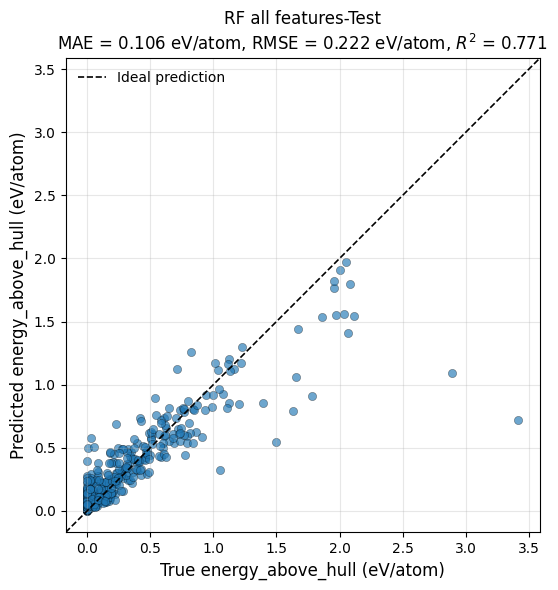

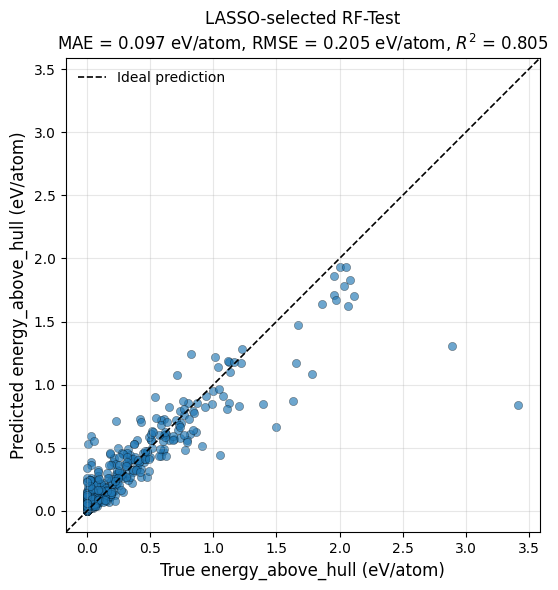

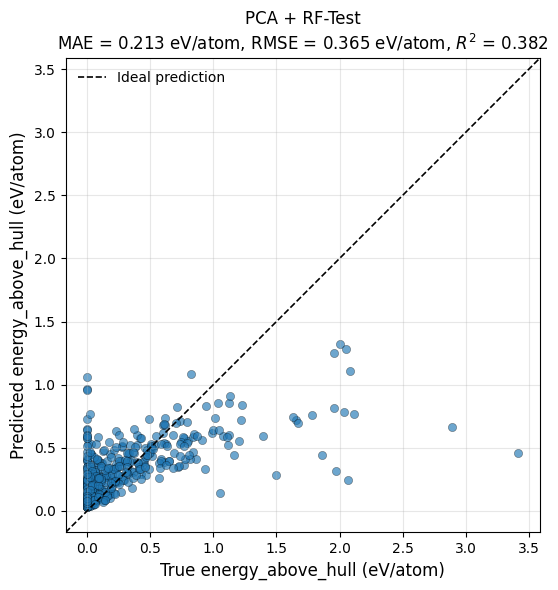

In [ ]:
# ============================================================
# Cell 17 — Predicted vs true plots, cleaner version
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Unit label
if "band_gap" in target_col.lower():
    unit = "eV"
elif "energy_above_hull" in target_col.lower():
    unit = "eV/atom"
else:
    unit = ""

predictions = {
    "RF all features": y_pred_rf_all,
    "LASSO-selected RF": y_pred_rf_lasso,
    "PCA + RF": y_pred_rf_pca
}

for model_name, y_pred in predictions.items():

    metrics = evaluate_model(y_test, y_pred)

    fig, ax = plt.subplots(figsize=(6, 6))

    ax.scatter(
        y_test,
        y_pred,
        alpha=0.65,
        s=35,
        edgecolor="black",
        linewidth=0.3
    )

    # Set equal x/y limits
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    pad = 0.05 * (max_val - min_val)

    plot_min = min_val - pad
    plot_max = max_val + pad

    ax.plot(
        [plot_min, plot_max],
        [plot_min, plot_max],
        "k--",
        linewidth=1.2,
        label="Ideal prediction"
    )

    ax.set_xlim(plot_min, plot_max)
    ax.set_ylim(plot_min, plot_max)
    ax.set_aspect("equal", adjustable="box")

    ax.set_xlabel(f"True {target_col} ({unit})", fontsize=12)
    ax.set_ylabel(f"Predicted {target_col} ({unit})", fontsize=12)

    ax.set_title(
        f"{model_name}-Test\n"
        f"MAE = {metrics['MAE']:.3f} {unit}, "
        f"RMSE = {metrics['RMSE']:.3f} {unit}, "
        f"$R^2$ = {metrics['R2']:.3f}",
        fontsize=12
    )

    ax.grid(True, alpha=0.3)
    ax.legend(frameon=False)

    plt.tight_layout()
    plt.show()

Parity plot inputs:
X_train_scaled: (1743, 301)
X_test_scaled: (436, 301)
X_train_lasso: (1743, 171)
X_test_lasso: (436, 171)
X_train_pca: (1743, 89)
X_test_pca: (436, 89)


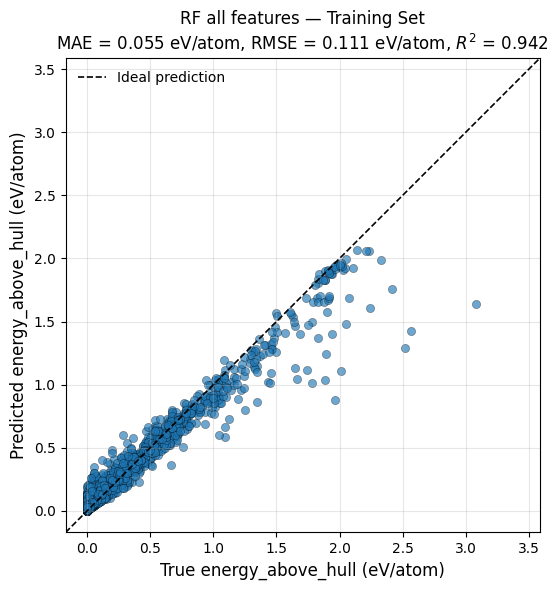

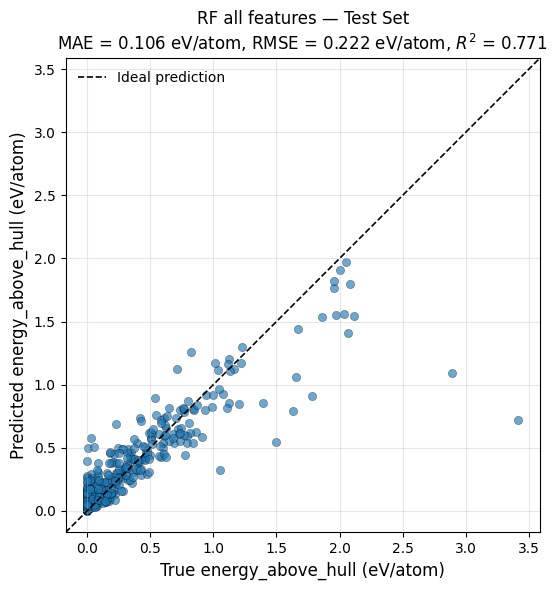

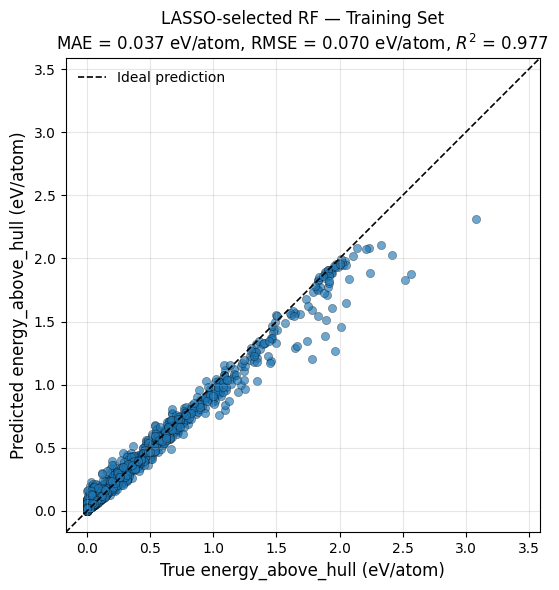

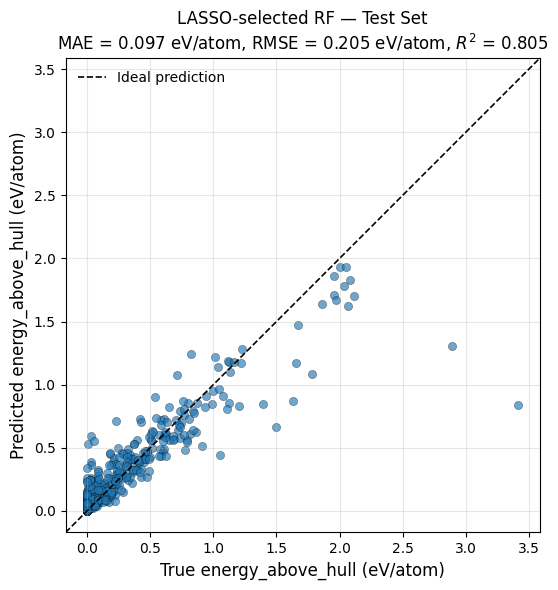

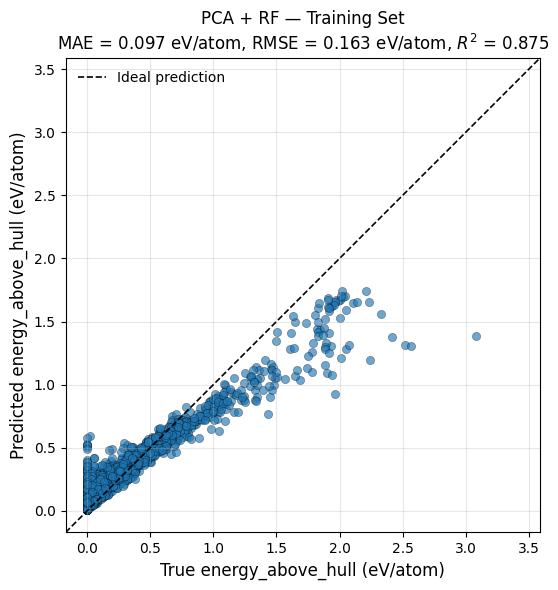

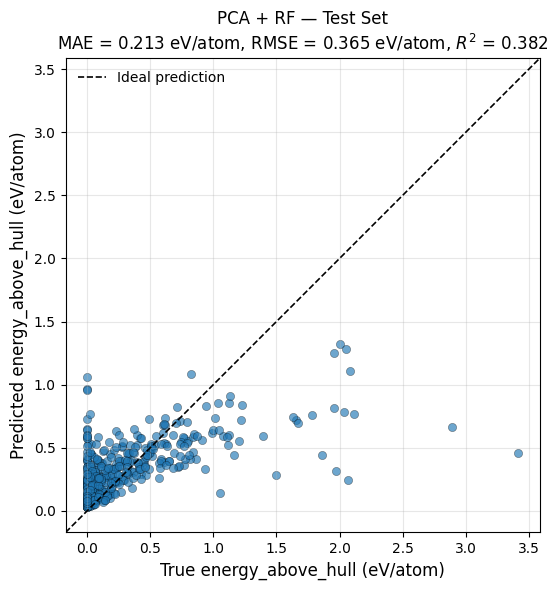

In [ ]:
# ============================================================
# Cell 18 — Parity plots for TRAINING and TEST sets
# RF all features, LASSO-selected RF, PCA + RF
# Fixed: rebuilds transformed inputs if they are missing.
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Unit label
if "band_gap" in target_col.lower():
    unit = "eV"
elif "energy_above_hull" in target_col.lower():
    unit = "eV/atom"
else:
    unit = ""

def evaluate_model(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

# ------------------------------------------------------------
# Rebuild transformed inputs if needed
# ------------------------------------------------------------

# LASSO-selected feature matrices
if "X_train_lasso" not in globals() or "X_test_lasso" not in globals():
    if "selected_features" not in globals():
        raise NameError("selected_features is not defined. Run Cells 11–12 first.")
    X_train_lasso = X_train_scaled[selected_features].copy()
    X_test_lasso = X_test_scaled[selected_features].copy()

# PCA-transformed matrices
if "X_train_pca" not in globals() or "X_test_pca" not in globals():
    if "pca" not in globals():
        raise NameError("pca is not defined. Run Cell 14 first.")
    X_train_pca = pca.transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

print("Parity plot inputs:")
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)
print("X_train_lasso:", X_train_lasso.shape)
print("X_test_lasso:", X_test_lasso.shape)
print("X_train_pca:", X_train_pca.shape)
print("X_test_pca:", X_test_pca.shape)

# ------------------------------------------------------------
# Generate TRAIN and TEST predictions
# ------------------------------------------------------------

predictions = {
    "RF all features": {
        "train": rf_all.predict(X_train_scaled),
        "test": rf_all.predict(X_test_scaled),
    },
    "LASSO-selected RF": {
        "train": rf_lasso.predict(X_train_lasso),
        "test": rf_lasso.predict(X_test_lasso),
    },
    "PCA + RF": {
        "train": rf_pca.predict(X_train_pca),
        "test": rf_pca.predict(X_test_pca),
    }
}

# ------------------------------------------------------------
# Plot parity plots
# ------------------------------------------------------------

for model_name, preds in predictions.items():

    y_pred_train = preds["train"]
    y_pred_test = preds["test"]

    train_metrics = evaluate_model(y_train, y_pred_train)
    test_metrics = evaluate_model(y_test, y_pred_test)

    # Same axis limits for train and test
    min_val = min(
        y_train.min(),
        y_test.min(),
        y_pred_train.min(),
        y_pred_test.min()
    )

    max_val = max(
        y_train.max(),
        y_test.max(),
        y_pred_train.max(),
        y_pred_test.max()
    )

    pad = 0.05 * (max_val - min_val)
    plot_min = min_val - pad
    plot_max = max_val + pad

    # -----------------------------
    # Training parity plot
    # -----------------------------

    fig, ax = plt.subplots(figsize=(6, 6))

    ax.scatter(
        y_train,
        y_pred_train,
        alpha=0.65,
        s=35,
        edgecolor="black",
        linewidth=0.3
    )

    ax.plot(
        [plot_min, plot_max],
        [plot_min, plot_max],
        "k--",
        linewidth=1.2,
        label="Ideal prediction"
    )

    ax.set_xlim(plot_min, plot_max)
    ax.set_ylim(plot_min, plot_max)
    ax.set_aspect("equal", adjustable="box")

    ax.set_xlabel(f"True {target_col} ({unit})", fontsize=12)
    ax.set_ylabel(f"Predicted {target_col} ({unit})", fontsize=12)

    ax.set_title(
        f"{model_name} — Training Set\n"
        f"MAE = {train_metrics['MAE']:.3f} {unit}, "
        f"RMSE = {train_metrics['RMSE']:.3f} {unit}, "
        f"$R^2$ = {train_metrics['R2']:.3f}",
        fontsize=12
    )

    ax.grid(True, alpha=0.3)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()

    # -----------------------------
    # Test parity plot
    # -----------------------------

    fig, ax = plt.subplots(figsize=(6, 6))

    ax.scatter(
        y_test,
        y_pred_test,
        alpha=0.65,
        s=35,
        edgecolor="black",
        linewidth=0.3
    )

    ax.plot(
        [plot_min, plot_max],
        [plot_min, plot_max],
        "k--",
        linewidth=1.2,
        label="Ideal prediction"
    )

    ax.set_xlim(plot_min, plot_max)
    ax.set_ylim(plot_min, plot_max)
    ax.set_aspect("equal", adjustable="box")

    ax.set_xlabel(f"True {target_col} ({unit})", fontsize=12)
    ax.set_ylabel(f"Predicted {target_col} ({unit})", fontsize=12)

    ax.set_title(
        f"{model_name} — Test Set\n"
        f"MAE = {test_metrics['MAE']:.3f} {unit}, "
        f"RMSE = {test_metrics['RMSE']:.3f} {unit}, "
        f"$R^2$ = {test_metrics['R2']:.3f}",
        fontsize=12
    )

    ax.grid(True, alpha=0.3)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()
